In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import xarray as xr
import geopandas as gpd
import seaborn as sns

from scipy import interpolate
from shapely.validation import make_valid
from shapely.geometry import Point
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
from matplotlib.lines import Line2D
from matplotlib.transforms import ScaledTranslation

path_to_scenarios = '/home/abhis/india_power/scenarios'
path_to_csvs      = '/home/gterren/india_power/gridpath_india_viz/csvs'
path_to_data      = '/home/gterren/india_power/gridpath_india_viz/data/'
path_to_input     = '/home/gterren/india_power/input_data'
path_to_images    = '/home/gterren/india_power/gridpath_india_viz/images/'

In [2]:
tech_labels_ = pd.read_csv(path_to_csvs + '/technology_labels.csv') 
scenarios_   = pd.read_csv(path_to_csvs + '/ra-scenario_labels.csv') 

In [3]:
_bhutan = gpd.read_file(path_to_data + r"map/bhutan/bt.shp").to_crs("epsg:4326")
_india  = gpd.read_file(path_to_data + r"map/india/india-polygon.shp").to_crs("epsg:4326")

# Assuming your GeoDataFrame is named 'gdf' and the geometry column is 'geometry'
_india['geometry'] = _india['geometry'].apply(lambda geom: make_valid(geom) if geom else None)
_india = _india.dropna(subset = ['geometry'])  # Remove rows with None geometry

_nothern      = _india.loc[[4, 10, 11, 22, 24, 25, 30, 31, 35, 36]].dissolve().buffer(.025)#.to_crs(epsg=3395).to_crs("epsg:4326")
_northeastern = _india.loc[[1, 2, 18, 19, 20, 21, 29]].dissolve()
_western      = _india.loc[[5, 6, 7, 8, 9, 16, 17]].dissolve()
_southern     = _india.loc[[13, 14, 23, 27, 28, 34]].dissolve()
_eastern      = _india.loc[[3, 12, 26, 32, 33]].dissolve()
_regions      = pd.concat([_nothern, _northeastern, _western, _eastern], axis = 0)


/tmp/ipykernel_84356/710208428.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  _nothern      = _india.loc[[4, 10, 11, 22, 24, 25, 30, 31, 35, 36]].dissolve().buffer(.025)#.to_crs(epsg=3395).to_crs("epsg:4326")


In [4]:
def _opt_dist(x_, y_, d = 1.4, delta = 0.1):
    
    def __update_position(x, x_0, z):
        return x + ((x - x_0)/z)*delta, x_0 + ((x_0 - x)/z)*delta  
    
    while True:
        flag = True
        for i in range(x_.shape[0]):
            for j in range(x_.shape[0]):
                if i != j:
                    z = np.sqrt( (x_[j] - x_[i])**2 + (y_[j] - y_[i])**2 )
                    if z < d:
                        x_[j], x_[i] = __update_position(x_[j], x_[i], z)
                        y_[j], y_[i] = __update_position(y_[j], y_[i], z)
                        flag = False
        if flag:
            break

    return x_, y_

city_ = pd.read_csv(path_to_input + r"/transmission/major_cities_india.csv")
city_ = city_.drop(columns = ['state', 'major_city'])
city_ = city_.rename(columns = {'acronym': 'load_zone_abr'})

load_zones_ = pd.read_csv(path_to_input + r"/load_zones.csv").drop(columns = ['state', 'rps_zone'])
load_zones_ = pd.merge(city_, load_zones_, on  = 'load_zone_abr', 
                                           how = 'inner').rename(columns = {'region_x': 'region'})

load_zones_p_ = load_zones_.copy()

load_zones_p_['longitude'], load_zones_p_['latitude'] = _opt_dist(load_zones_p_['longitude'].to_numpy(), load_zones_p_['latitude'].to_numpy())
               
# load_zones_p_.loc[13, 'latitude']  -= .1
# load_zones_p_.loc[15, 'longitude'] -= .1
# load_zones_p_.loc[29, 'longitude'] -= .4
# load_zones_p_.loc[30, 'longitude'] += .15
# load_zones_p_.loc[31, 'latitude']  += .15
# load_zones_p_.loc[34, 'latitude']  += .325
# load_zones_p_.loc[34, 'longitude'] += .5
# print(load_zones_p_)

load_zones_p_.loc[31, 'latitude'] = load_zones_.loc[31, 'latitude']
load_zones_p_.loc[7, 'latitude']  = load_zones_.loc[7, 'latitude']
    
load_zones_p_.loc[31, 'latitude']  += .05
load_zones_p_.loc[31, 'longitude'] += .15

load_zones_p_.loc[13, 'latitude']  -= .1
load_zones_p_.loc[15, 'longitude'] -= .175
load_zones_p_.loc[29, 'longitude'] -= .6
load_zones_p_.loc[29, 'latitude'] -= .15

#load_zones_p_.loc[30, 'longitude'] += .5
load_zones_p_.loc[34, 'latitude']  += .325
load_zones_p_.loc[34, 'longitude'] += .5

load_zones_p_.loc[7, 'latitude']  += 1.3
load_zones_p_.loc[7, 'longitude'] -= 1.55

load_zones_p_.loc[28, 'latitude']  += .4
#load_zones_p_.loc[28, 'longitude'] -= .125

#load_zones_p_.loc[26, 'latitude']  += .2
load_zones_p_.loc[26, 'longitude'] += .7

#load_zones_p_.loc[19, 'latitude']  += .1
load_zones_p_.loc[19, 'longitude'] -= .3

load_zones_p_.loc[8, 'longitude'] += .25

load_zones_p_.loc[13, 'latitude']  -= .15
load_zones_p_.loc[13, 'longitude'] += .15

load_zones_p_.loc[16, 'longitude'] += .125

print(load_zones_p_)

   load_zone_abr         region   latitude  longitude           load_zone  \
0             AP       Southern  17.704167  83.297778      Andhra_Pradesh   
1             AR  North-Eastern  27.398913  93.594569   Arunachal_Pradesh   
2             AS  North-Eastern  26.560107  91.648131               Assam   
3             BR        Eastern  25.600000  85.100000               Bihar   
4             CG        Central  21.250000  81.630000        Chhattisgarh   
5             GA        Western  15.398056  73.811111                 Goa   
6             GJ        Western  23.030000  72.580000             Gujarat   
7             HR       Northern  29.721100  76.069233             Haryana   
8             HP       Northern  31.778866  77.691151    Himachal_Pradesh   
9             JH        Eastern  22.792500  86.184167           Jharkhand   
10            KA       Southern  12.978889  77.591667           Karnataka   
11            KL       Southern   8.487500  76.952500              Kerala   

# Process transmission line characteristics

In [ ]:
# Load and processing tranmission lines characteristics in all iteratiions
def _processing_tranmission(scenarios_):
    dfs_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, dirnames, filenames in os.walk(path_to_scenario):
            # Processing scenarios results folder only
            if dirpath.split('/')[-1] == 'results':
                print(scenario)

                df_ = pd.read_csv(os.path.join(dirpath, 'transmission_period.csv'), low_memory = False)
                
                df_ = df_[['transmission_line', 
                           'load_zone_from', 
                           'load_zone_to', 
                           'max_mw']].rename(columns = {'max_mw': 'power_mw'})

                df_ = df_.groupby(['transmission_line',
                                   'load_zone_from', 
                                   'load_zone_to']).agg({'power_mw': 'sum'}).reset_index(drop = False)
                
                # Add iteration descriptors to dataframe
                df_['W-H-A'] = r'{}-{}-{}'.format(dirpath.split('/')[-4].split('_')[-1], 
                                                  dirpath.split('/')[-3].split('_')[-1], 
                                                  dirpath.split('/')[-2].split('_')[-1])
                
                dfs_.append(df_)

    return pd.concat(dfs_).reset_index(drop = True)

df_tx_ = _processing_tranmission(scenarios_)
print(df_tx_.head())

capex_pier_prm_108_cc_90_hardovergen_2040_1
capex_pier_prm_108_cc_90_hardovergen_2040_2
capex_pier_prm_108_cc_90_hardovergen_2040_3
capex_pier_prm_108_cc_90_hardovergen_2040_4
capex_pier_prm_108_cc_90_hardovergen_2040_5
capex_pier_prm_108_cc_90_hardovergen_2040_6
capex_pier_prm_108_cc_90_hardovergen_2040_7
capex_pier_prm_108_cc_90_hardovergen_2040_8
capex_pier_prm_108_cc_90_hardovergen_2040_9
capex_pier_prm_108_cc_90_hardovergen_2040_10
capex_pier_prm_108_cc_90_hardovergen_2040_11
capex_pier_prm_108_cc_90_hardovergen_2040_12
capex_pier_prm_108_cc_90_hardovergen_2040_13
capex_pier_prm_108_cc_90_hardovergen_2040_14
capex_pier_prm_108_cc_90_hardovergen_2040_15
capex_pier_prm_108_cc_90_hardovergen_2040_16
capex_pier_prm_108_cc_90_hardovergen_2040_17
capex_pier_prm_108_cc_90_hardovergen_2040_18
           transmission_line  load_zone_from load_zone_to      power_mw  W-H-A
0   Andhra_Pradesh-Karnataka  Andhra_Pradesh    Karnataka  11177.000000  1-1-1
1      Andhra_Pradesh-Odisha  Andhra_Prad

# Process tranmission flow timepoints

In [14]:
# Load and processing tranmission flows in all interations
def _processing_tranmission_flow_timepoints(scenarios_):
    dfs_ = []
    for scenario in scenarios_['scenario']:
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, dirnames, filenames in os.walk(path_to_scenario):
            # Processing scenarios results folder only
            if dirpath.split('/')[-1] == 'results':
                print(scenario)

                df_ = pd.read_csv(os.path.join(dirpath, 'transmission_timepoint.csv'), low_memory = False)
                
                df_ = df_[['timepoint', 
                           'load_zone_from', 
                           'load_zone_to', 
                           'transmission_flow_mw', 
                           'transmission_losses_lz_from', 
                           'transmission_losses_lz_to']]
                
                df_.loc[df_['load_zone_to'] == 'Daman_Diu', 'load_zone_to'] = 'Dadra_Nagar_Haveli'
                df_.loc[df_['load_zone_from'] == 'Daman_Diu', 'load_zone_from'] = 'Dadra_Nagar_Haveli'
                
                df_ = df_.groupby(['timepoint',
                                   'load_zone_from', 
                                   'load_zone_to']).agg({'transmission_flow_mw': 'sum',
                                                         'transmission_losses_lz_from': 'sum',
                                                         'transmission_losses_lz_to': 'sum'}).reset_index(drop = False)
                
                # Add iteration descriptors to dataframe
                df_['W-H-A'] = r'{}-{}-{}'.format(dirpath.split('/')[-4].split('_')[-1], 
                                                  dirpath.split('/')[-3].split('_')[-1], 
                                                  dirpath.split('/')[-2].split('_')[-1])
                
                dfs_.append(df_)

    return pd.concat(dfs_).reset_index(drop = True)

df_flow_ = _processing_tranmission_flow_timepoints(scenarios_)
print(df_flow_.head())

capex_pier_prm_108_cc_90_hardovergen_2040_1
capex_pier_prm_108_cc_90_hardovergen_2040_2
capex_pier_prm_108_cc_90_hardovergen_2040_3
capex_pier_prm_108_cc_90_hardovergen_2040_4
capex_pier_prm_108_cc_90_hardovergen_2040_5
capex_pier_prm_108_cc_90_hardovergen_2040_6
capex_pier_prm_108_cc_90_hardovergen_2040_7
capex_pier_prm_108_cc_90_hardovergen_2040_8
capex_pier_prm_108_cc_90_hardovergen_2040_9
capex_pier_prm_108_cc_90_hardovergen_2040_10
capex_pier_prm_108_cc_90_hardovergen_2040_11
capex_pier_prm_108_cc_90_hardovergen_2040_12
capex_pier_prm_108_cc_90_hardovergen_2040_13
capex_pier_prm_108_cc_90_hardovergen_2040_14
capex_pier_prm_108_cc_90_hardovergen_2040_15
capex_pier_prm_108_cc_90_hardovergen_2040_16
capex_pier_prm_108_cc_90_hardovergen_2040_17
capex_pier_prm_108_cc_90_hardovergen_2040_18
    timepoint     load_zone_from load_zone_to  transmission_flow_mw  \
0  2040040101     Andhra_Pradesh    Karnataka          11177.000000   
1  2040040101     Andhra_Pradesh       Odisha          -3

## Filter transmission flows by `timepoint`, `load_zone` and `iteration`

0.0 24817.153387029037


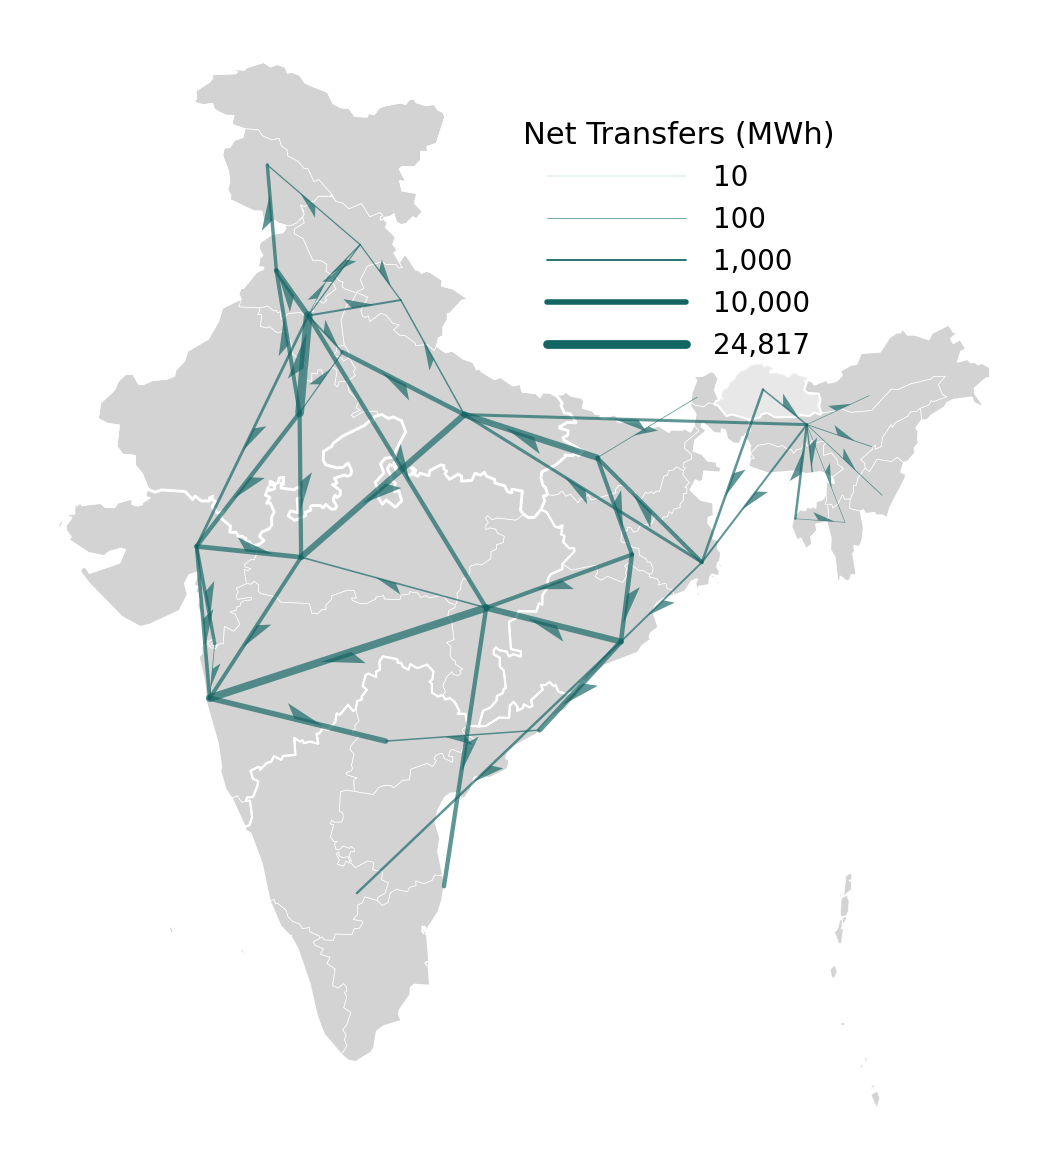

In [21]:
def _filter_transmission_timepoint(df_p_, timepoint, WHA):

    df_ = df_p_.copy()

    # Selecting timepoints, iteration, and load zone
    idx_1_ = (df_['timepoint'] == timepoint)
    idx_2_ = (df_['W-H-A'] == WHA)
    df_    = df_[idx_1_ & idx_2_].reset_index(drop = True).copy()

    return df_.copy()

def _plot_transmission_exchange(ax, df_, load_zones_, legend = True):
    
    def __f(x):
        return np.sqrt(np.absolute(x))/25.

    df_p_ = df_.copy()

    print(df_p_['transmission_flow_mw'].abs().min(), df_p_['transmission_flow_mw'].abs().max())
    for i in range(df_p_.shape[0]):
        load_zone_to_   = load_zones_.loc[load_zones_['load_zone'] == df_p_.loc[i, 'load_zone_to']]
        load_zone_from_ = load_zones_.loc[load_zones_['load_zone'] == df_p_.loc[i, 'load_zone_from']]

        lon_from = load_zone_from_['longitude'].to_numpy()[0]
        lon_to   = load_zone_to_['longitude'].to_numpy()[0]
        if lon_from < lon_to:
            x_ = np.concatenate([load_zone_from_['latitude'].to_numpy(), load_zone_to_['latitude'].to_numpy()], axis = 0)
            y_ = np.concatenate([load_zone_from_['longitude'].to_numpy(), load_zone_to_['longitude'].to_numpy()], axis = 0)
            exchange = df_p_.loc[i, 'transmission_flow_mw']

        else:
            x_ = np.concatenate([load_zone_to_['latitude'].to_numpy(), load_zone_from_['latitude'].to_numpy()], axis = 0)
            y_ = np.concatenate([load_zone_to_['longitude'].to_numpy(), load_zone_from_['longitude'].to_numpy()], axis = 0)
            exchange = - df_p_.loc[i, 'transmission_flow_mw']

        #print(df_p_.loc[i])
        #exchange = 1e6
        z = __f(exchange)
        w = np.sign(exchange)
        if z > 0.:
            line = ax.plot(y_, x_, 
                        lw             = z, 
                        zorder         = 10, 
                        color          = '#136564', 
                        solid_capstyle = 'round', 
                        alpha          = .675)

            l = .3 + np.sqrt(z)/4.
            
            dy = (y_[1] - y_[0])/2.
            dx = (x_[1] - x_[0])/2.
            ds = np.sqrt(dy**2 + dx**2)
            lx = dx/ds
            ly = dy/ds
                
            if w > 0.:
                ax.arrow(y_[0] + dy, x_[0] + dx, ly*l, lx*l, 
                        overhang   = 0.25, 
                        shape      = 'right', 
                        color      = '#136564',
                        ls         = 'None', 
                        head_width = l, 
                        zorder     = 11, 
                        alpha      = .675,
                        length_includes_head = True)
            else:
                ax.arrow(y_[0] + dy, x_[0] + dx, -ly*l, -lx*l, 
                        overhang   = 0.25, 
                        shape      = 'right', 
                        color      = '#136564',
                        ls         = 'None', 
                        head_width = l, 
                        zorder     = 11, 
                        alpha      = .675,
                        length_includes_head = True)


    _nothern.plot(ax = ax, zorder = 9, color = 'None', lw = 1.5, edgecolor = 'white')
    _northeastern.plot(ax = ax, zorder = 9, color = 'None', lw = 1.5, edgecolor = 'white')
    _western.plot(ax = ax, zorder = 9, color = 'None', lw = 1.5, edgecolor = 'white')
    _southern.plot(ax = ax, zorder = 9, color = 'None', lw = 1.5, edgecolor = 'white')
    _eastern.plot(ax = ax, zorder = 9, color = 'None', lw = 1.5, edgecolor = 'white')
    _bhutan.plot(ax = ax, zorder = 8, color = 'lightgray', lw = 1.5, alpha = .5, edgecolor = 'white')
    _india.plot(ax = ax, zorder = 8, color = 'lightgray', lw = 0.5, edgecolor = 'white')

    if legend:

        # #95cca3 #2cb7b5
        line1 = Line2D([], [], color = '#136564', lw = __f(10), solid_capstyle ='round')
        line2 = Line2D([], [], color = '#136564', lw = __f(100), solid_capstyle ='round')
        line3 = Line2D([], [], color = '#136564', lw = __f(1000), solid_capstyle ='round')
        line4 = Line2D([], [], color = '#136564', lw = __f(10000), solid_capstyle ='round')
        line5 = Line2D([], [], color = '#136564', lw = __f(24817), solid_capstyle ='round')

        ax.legend((line1, line2, line3, line4, line5), 
                ('10', '100', '1,000', '10,000', '24,817'), 
                title_fontsize = 22,
                title          = 'Net Transfers (MWh)',
                handlelength   = 5.,
                handletextpad  = 1.,
                labelspacing   = .5,
                frameon        = False, 
                bbox_to_anchor = (0.475, 0.925), 
                prop           = {'size': 20})

    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

    ax.set_xticks([], [])
    ax.set_yticks([], [])

# Transfers timepoint
timepoint = 2041020709

# Iteration descriptors
WHA = '17-17-17'

df_nt_flow_p_ = _filter_transmission_timepoint(df_flow_, timepoint, WHA)

fig, ax = plt.subplots(1, 1, figsize = (13.25, 15))

_plot_transmission_exchange(ax, df_nt_flow_p_, load_zones_p_, legend = True)

plt.savefig(path_to_images + '/transfers_map-{}-{}.png'.format(timepoint, WHA), 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.savefig(path_to_images + '/transfers_map-{}-{}.png'.format(timepoint, WHA), 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

/tmp/ipykernel_84356/369984814.py:8: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df_ = df_.set_index(['timepoint',


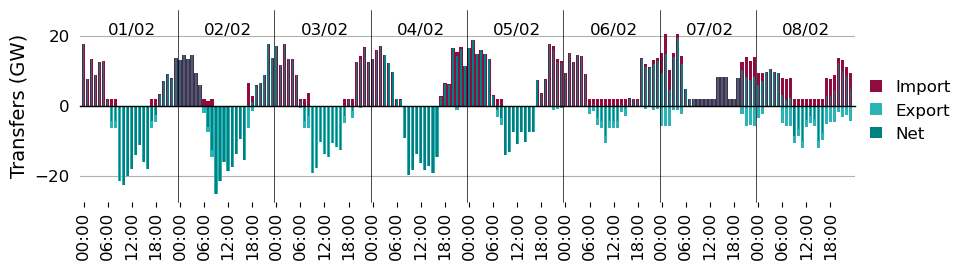

In [ ]:
def _plot_transmission_flow(ax, df_p_, ylim = 25, units = 1000. , ylabel = 'Transfers (GW)', legend = True):
    
    width = 0.8

    df_ = df_p_[['timepoint', 
                 'technology', 
                 'transmission_flow_mw']].copy()
    df_ = df_.set_index(['timepoint', 
                         'technology']).unstack(fill_value = 0).stack().reset_index().sort_values('timepoint')

    x_labels_ = df_['timepoint'].unique().astype(str)
    x_        = np.arange(x_labels_.shape[0])
    
    idx_ = df_['technology'] == 'Import' 
    
    ax.bar(x_, df_.loc[idx_, 'transmission_flow_mw']/units, width, 
           label  = 'Import', 
           color  = '#2cb4b4', 
           zorder = 8)
    
    ax.bar(x_, df_.loc[~idx_, 'transmission_flow_mw']/units, width, 
           label  = 'Export', 
           color  = 'teal', 
           zorder = 8)
    
    df_ = df_p_[['timepoint', 'transmission_flow_mw']].copy()
    df_ = df_.groupby(['timepoint']).agg({'transmission_flow_mw': 'sum'}).reset_index(drop = False).sort_values('timepoint')
    
    ax.bar(x_, df_['transmission_flow_mw']/units, width/2., 
           label  = 'Net', 
           color  = '#900C3F', 
           zorder = 9)

    ax.set_xticks(x_[::6], ['{:02}:00'.format(int(x_label[-2:]) - 1)
                             for x_label in x_labels_][::6], rotation = 90)
        
    for x, x_label in zip(x_[12::24], x_labels_[12::24]):
        ax.text(x, df_p_['transmission_flow_mw'].max()*1.05/units, 
                f'{x_label[-4:-2]}/{x_label[-6:-4]}', ha='center', va='center', size = 12)
    
    for x in x_[24::24]:
        ax.axvline(x - .5, 
                   linewidth = .5, 
                   linestyle = '-', 
                   color     = 'k', 
                   clip_on   = False, 
                   zorder    = 10)

    ax.set_ylabel(ylabel, fontsize = 14)

    ax.xaxis.set_tick_params(labelsize = 12)
    ax.yaxis.set_tick_params(labelsize = 12, left = False)
    ax.set_xlim(x_[0] - 1., x_[-1] + 1.)
    ax.set_ylim(-ylim, ylim)

    ax.axhline(0, 
               linewidth = 1., 
               linestyle = '-', 
               color     = 'k', 
               clip_on   = False, 
               zorder    = 10)
    
    if legend:
        ax.legend(loc            = 'center left', 
                  bbox_to_anchor = (1., 0.475), 
                  handlelength   = .75,
                  frameon        = False,
                  prop           = {'size': 12})
        
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)
    ax.grid(axis = 'y')

def _filter_transmission_timepoints(df_p_, load_zone, timepoint_0, timepoint_1, WHA):

    df_ = df_p_.copy()

    # Selecting timepoints, iteration, and load zone
    idx_1_ = (df_['timepoint'] >= timepoint_0) & (df_['timepoint'] <= timepoint_1) 
    idx_2_ = (df_['W-H-A'] == WHA) 
    idx_3_ = (df_['load_zone_from'] == load_zone) | (df_['load_zone_to'] == load_zone) 
    df_    = df_[idx_1_ & idx_2_ & idx_3_].reset_index(drop = True).copy()

    idx_ = df_['load_zone_to'] == load_zone

    # Flip the load zone names
    df_.loc[idx_, 'load_zone_to']   = df_.loc[idx_, 'load_zone_from']
    df_.loc[idx_, 'load_zone_from'] = load_zone

    # Flip the sign of the transmission flow
    df_.loc[idx_, 'transmission_flow_mw'] = - df_.loc[idx_, 'transmission_flow_mw']

    df_['transmission_losses_lz_from'] += df_['transmission_losses_lz_to'] 

    df_['transmission_flow_mw'] = - df_['transmission_flow_mw']

    df_['technology'] = ''

    idx_ = df_['transmission_flow_mw'] > 0.

    df_.loc[idx_, 'technology']  = 'Import'
    df_.loc[~idx_, 'technology'] = 'Export'

    df_ = df_.drop(columns = ['transmission_losses_lz_to', 
                              'load_zone_to']).rename(columns = {'load_zone_from': 'load_zone', 
                                                                 'transmission_losses_lz_from': 'transmission_losses_mw'})
    
    df_ = df_.groupby(['timepoint', 
                       'technology']).agg({'transmission_flow_mw': 'sum',
                                           'transmission_losses_mw': 'sum'}).reset_index(drop = False)
    
    return df_.copy()

# Load zone to be analyzed
load_zone = 'Karnataka'

# Begining and ending timepoints
timepoint_0 = 2041020101
timepoint_1 = 2041020824

# Iteration descriptors
WHA = '17-17-17'

df_st_flow_ = _filter_transmission_timepoints(df_flow_, load_zone, timepoint_0, timepoint_1, WHA)

fig = plt.figure(figsize = (10, 2.5))
_ax = plt.subplot(111)

_plot_transmission_flow(_ax, df_st_flow_, ylim = 27.5)

plt.savefig(path_to_images + '/transfers-{}-{}-{}-{}.png'.format(load_zone, str(timepoint_0), str(timepoint_1), WHA), 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.savefig(path_to_images + '/transfers-{}-{}-{}-{}.png'.format(load_zone, str(timepoint_0), str(timepoint_1), WHA), 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.show()


['Andhra_Pradesh' 'Karnataka' 'Kerala' 'Tamil_Nadu' 'Telangana'
 'Puducherry']
      timepoint  transmission_flow_mw  transmission_losses_mw
0    2041020101          -9476.220191             1252.650637
1    2041020102          -8279.292120             1030.977261
2    2041020103         -17646.902821             1149.204620
3    2041020104          -9469.806516              928.121086
4    2041020105         -16207.330360             1021.186252
..          ...                   ...                     ...
187  2041020820            292.680811             1051.468164
188  2041020821          -5004.158636             1471.801245
189  2041020822           1464.189560             1513.397334
190  2041020823          -2382.171121             1169.447745
191  2041020824          -3609.857971             1187.124721

[192 rows x 3 columns]


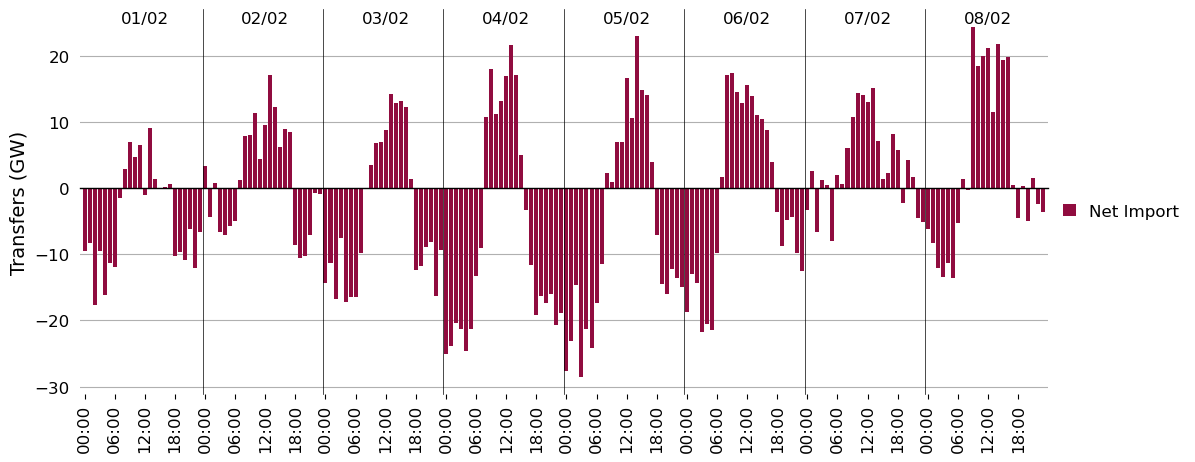

In [10]:
def _filter_net_transfers_timepoints(df_p_, load_zones_, timepoint_0, timepoint_1, WHA):

    df_ = df_p_.copy()

    # Selecting timepoints, iteration, and load zone
    idx_1_ = (df_['timepoint'] >= timepoint_0) & (df_['timepoint'] <= timepoint_1) 
    idx_2_ = (df_['W-H-A'] == WHA) 
    idx_3_ = df_['load_zone_from'].isin(load_zones_) | df_['load_zone_to'].isin(load_zones_)
    df_    = df_[idx_1_ & idx_2_ & idx_3_].reset_index(drop = True).copy()

    #df_['transmission_flow_mw'] = df_['transmission_flow_mw'].abs()
    
    df_ = df_.groupby(['timepoint']).agg({'transmission_flow_mw': 'sum',
                                          'transmission_losses_lz_to': 'sum',
                                          'transmission_losses_lz_from': 'sum'}).reset_index(drop = False)
    
    df_['transmission_losses_lz_to'] += df_['transmission_losses_lz_from']

    df_ = df_.drop(columns = ['transmission_losses_lz_from']).rename(columns = {'transmission_losses_lz_to': 
                                                                                'transmission_losses_mw'})

    return df_.copy()

def _plot_net_flow(ax, df_, 
                   units  = 1000., 
                   ylabel = 'Transfers (GW)', 
                   legend = True):
    
    width = 0.8

    x_labels_ = df_['timepoint'].unique().astype(str)
    x_        = np.arange(x_labels_.shape[0])
        
    ax.bar(x_, df_['transmission_flow_mw']/units, width, 
           label  = 'Net Import', 
           color  = '#900C3F', 
           zorder = 8)
    
    ax.set_xticks(x_[::6], ['{:02}:00'.format(int(x_label[-2:]) - 1)
                             for x_label in x_labels_][::6], rotation = 90)
        
    for x, x_label in zip(x_[12::24], x_labels_[12::24]):
        ax.text(x, df_['transmission_flow_mw'].max()*1.05/units, 
                f'{x_label[-4:-2]}/{x_label[-6:-4]}', ha='center', va='center', size = 12)
    
    for x in x_[24::24]:
        ax.axvline(x - .5, 
                   linewidth = .5, 
                   linestyle = '-', 
                   color     = 'k', 
                   clip_on   = False, 
                   zorder    = 10)

    ax.set_ylabel(ylabel, fontsize = 14)

    ax.xaxis.set_tick_params(labelsize = 12)
    ax.yaxis.set_tick_params(labelsize = 12, left = False)
    ax.set_xlim(x_[0] - 1., x_[-1] + 1.)

    ax.axhline(0, 
               linewidth = 1., 
               linestyle = '-', 
               color     = 'k', 
               clip_on   = False, 
               zorder    = 10)
    
    if legend:
        ax.legend(loc            = 'center left', 
                  bbox_to_anchor = (1., 0.475), 
                  handlelength   = .75,
                  frameon        = False,
                  prop           = {'size': 12})
        
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)
    ax.grid(axis = 'y')


# Load zone to be analyzed
load_zones_ = load_zones_p_.loc[load_zones_p_['region'] == 'Southern', 'load_zone'].to_numpy()
#load_zones_ = load_zones_p_.loc[[1, 2, 3], 'load_zone'].to_numpy()
#load_zones_ = ['Karnataka']
print(load_zones_)

# Begining and ending timepoints
timepoint_0 = 2041020101
timepoint_1 = 2041020824

# Iteration descriptors
WHA = '17-17-17'

df_net_flow_ = _filter_net_transfers_timepoints(df_flow_, load_zones_, timepoint_0, timepoint_1, WHA)
print(df_net_flow_)

fig = plt.figure(figsize = (12.5, 5))
_ax = plt.subplot(111)

_plot_net_flow(_ax, df_net_flow_, 
               units  = 1000., 
               ylabel = 'Transfers (GW)', 
               legend = True)

plt.show()

